In [1]:
# Unsupervised ML
# Data decomposition -- pca (principal composition analysis)
# Scaling
# Clustering KMeans algorithm

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# load dataset 'mpg'
data = sns.load_dataset('mpg')
data.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [6]:
# take '5 columns only'
df = data[['cylinders','displacement','horsepower','weight','acceleration']]

In [7]:
df

,cylinders,displacement,horsepower,weight,acceleration
0,8,307.0,130.0,3504,12.0
1,8,350.0,165.0,3693,11.5
2,8,318.0,150.0,3436,11.0
3,8,304.0,150.0,3433,12.0
4,8,302.0,140.0,3449,10.5
...,...,...,...,...,...
393,4,140.0,86.0,2790,15.6
394,4,97.0,52.0,2130,24.6
395,4,135.0,84.0,2295,11.6
396,4,120.0,79.0,2625,18.6


In [8]:
# perform clustering algorithm on 'df' dataset

In [9]:
# since 'df' is 5D dataset cannot be plot so, decompose to 2D 
# check any null values 'df'

In [10]:
df.isna().sum()

cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
dtype: int64

In [11]:
df = df.dropna()
df.isna().sum()

cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
dtype: int64

In [12]:
# use PCA for data decomposition
from sklearn.decomposition import PCA

In [14]:
# n_component = 2 i.e 2D dataset
pca = PCA(n_components=2)
pca

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",2
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

In [15]:
df_pca = pca.fit_transform(df)
df_pca

array([[ 5.36437175e+02,  5.07235758e+01],
       [ 7.30333848e+02,  7.90367466e+01],
       [ 4.70973760e+02,  7.53399238e+01],
       [ 4.66393605e+02,  6.24217398e+01],
       [ 4.81660073e+02,  5.56681930e+01],
       [ 1.38390781e+03,  8.54226453e+01],
       [ 1.40052974e+03,  1.14099858e+02],
       [ 1.35704247e+03,  1.04452563e+02],
       [ 1.47131745e+03,  1.07928381e+02],
       [ 8.91735627e+02,  1.05481262e+02],
       [ 6.05256297e+02,  1.27499533e+02],
       [ 6.45615680e+02,  7.83500529e+01],
       [ 8.02970979e+02,  1.13728678e+02],
       [ 1.42126342e+02,  2.69617616e+02],
       [-6.10827609e+02, -6.72266499e+00],
       [-1.43482760e+02,  1.80389326e+01],
       [-2.01858278e+02,  2.67058174e+01],
       [-3.87842342e+02,  4.66376674e+01],
       [-8.53156383e+02,  5.29225307e+00],
       [-1.14764008e+03,  2.81833416e+01],
       [-3.13683413e+02, -4.82593968e+01],
       [-5.54132697e+02, -2.08764091e+01],
       [-6.08882040e+02, -1.56870356e+01],
       [-7.

In [18]:
# convert array to datafram
df_pca = pd.DataFrame(df_pca, columns=['A','B'])
df_pca

,A,B
0,536.437175,50.723576
1,730.333848,79.036747
2,470.973760,75.339924
3,466.393605,62.421740
4,481.660073,55.668193
...,...,...
387,-193.153983,-34.356847
388,-854.572860,-5.792902
389,-685.172071,20.228680
390,-359.508924,-35.546326


<Axes: xlabel='A', ylabel='B'>

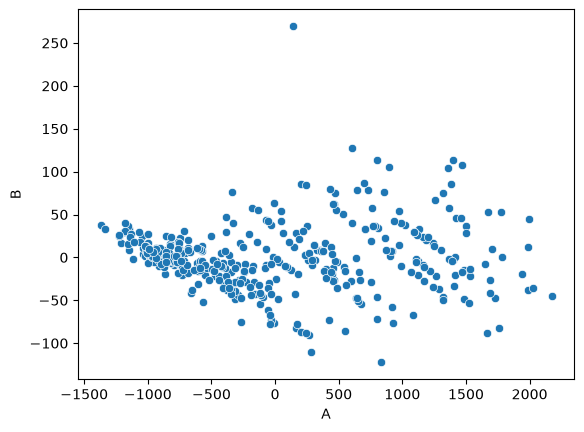

In [19]:
# plot
sns.scatterplot(x='A',y='B', data=df_pca)

In [20]:
# use KMeans algorithm for clustering
from sklearn.cluster import KMeans

In [21]:
# calculate wccs values
wccs = []

In [23]:
# lets take 8 clusters first
for x in range(2,10):
    kmeans = KMeans(n_clusters=x)
    kmeans.fit(df_pca)
    wccs.append(kmeans.inertia_)

In [24]:
wccs

[72851039.64926834,
 33831613.68630393,
 18705978.538986884,
 13444271.057707228,
 10066162.234264428,
 7827341.009531898,
 5735938.266626646,
 4709582.417116513]

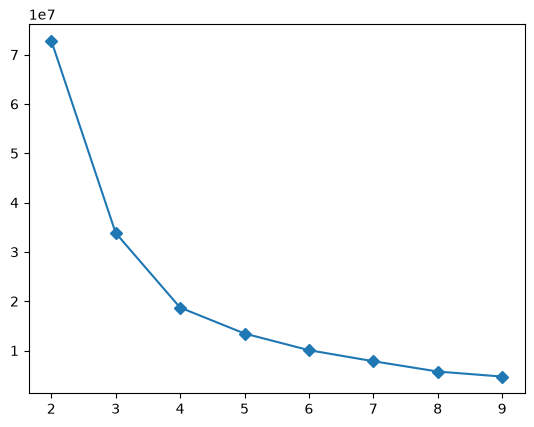

In [26]:
# plot the wccs to find the n_clusters
plt.plot(range(2,10), wccs, marker='D')

In [27]:
# from the graph, till 4 value dropped sharply, after 4 only slight drop, so we select 4 as clusters
kmeans = KMeans(n_clusters=4)
kmeans.fit(df_pca)
df_pca['label']=kmeans.labels_

In [28]:
df_pca

,A,B,label
0,536.437175,50.723576,3
1,730.333848,79.036747,3
2,470.973760,75.339924,3
3,466.393605,62.421740,3
4,481.660073,55.668193,3
...,...,...,...
387,-193.153983,-34.356847,0
388,-854.572860,-5.792902,2
389,-685.172071,20.228680,2
390,-359.508924,-35.546326,0


<Axes: xlabel='A', ylabel='B'>

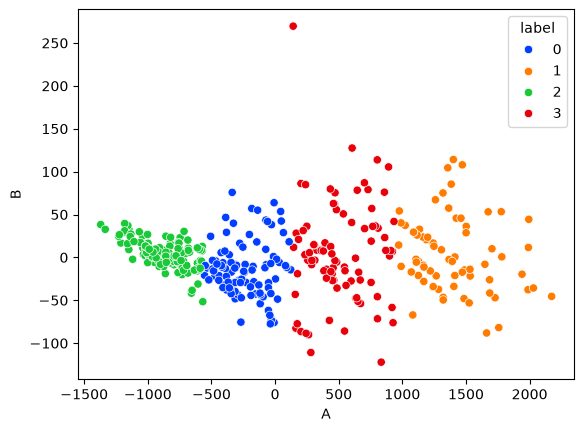

In [29]:
# plot on scatter and group by label
sns.scatterplot(x='A',y='B',data=df_pca, hue='label', palette='bright')

In [30]:
# Still the clustering is not clear...since the dataset columns 'A','B', has huge diff value.
# use MinMaxScaler on 'df' dataset
df

,cylinders,displacement,horsepower,weight,acceleration
0,8,307.0,130.0,3504,12.0
1,8,350.0,165.0,3693,11.5
2,8,318.0,150.0,3436,11.0
3,8,304.0,150.0,3433,12.0
4,8,302.0,140.0,3449,10.5
...,...,...,...,...,...
393,4,140.0,86.0,2790,15.6
394,4,97.0,52.0,2130,24.6
395,4,135.0,84.0,2295,11.6
396,4,120.0,79.0,2625,18.6


In [31]:
from sklearn.preprocessing import MinMaxScaler

In [32]:
scaler = MinMaxScaler()

In [33]:
df_scaled = scaler.fit_transform(df)
df_scaled

array([[1.        , 0.61757106, 0.45652174, 0.5361497 , 0.23809524],
       [1.        , 0.72868217, 0.64673913, 0.58973632, 0.20833333],
       [1.        , 0.64599483, 0.56521739, 0.51686986, 0.17857143],
       ...,
       [0.2       , 0.17312661, 0.20652174, 0.19336547, 0.21428571],
       [0.2       , 0.13436693, 0.17934783, 0.2869294 , 0.63095238],
       [0.2       , 0.13178295, 0.19565217, 0.31386447, 0.67857143]],
      shape=(392, 5))

In [34]:
# array into dataframe
df_scaled = pd.DataFrame(df_scaled, columns = df.columns)
df_scaled

,cylinders,displacement,horsepower,weight,acceleration
0,1.0,0.617571,0.456522,0.536150,0.238095
1,1.0,0.728682,0.646739,0.589736,0.208333
2,1.0,0.645995,0.565217,0.516870,0.178571
3,1.0,0.609819,0.565217,0.516019,0.238095
4,1.0,0.604651,0.510870,0.520556,0.148810
...,...,...,...,...,...
387,0.2,0.186047,0.217391,0.333711,0.452381
388,0.2,0.074935,0.032609,0.146583,0.988095
389,0.2,0.173127,0.206522,0.193365,0.214286
390,0.2,0.134367,0.179348,0.286929,0.630952


In [39]:
# df_scaled is 5D dataset, first dempose into 2D dataset using PCA
pca = PCA(n_components=2)

In [40]:
df_scaled_pca = pca.fit_transform(df_scaled)
df_scaled_pca

array([[ 6.17213583e-01, -6.01814453e-02],
       [ 7.71073334e-01, -1.32589783e-01],
       [ 6.73646884e-01, -1.53373805e-01],
       [ 6.44344658e-01, -1.03978179e-01],
       [ 6.39947233e-01, -1.61541653e-01],
       [ 1.03459674e+00, -2.13903891e-01],
       [ 1.12310157e+00, -3.02910024e-01],
       [ 1.09520737e+00, -3.24353214e-01],
       [ 1.13227174e+00, -2.55416483e-01],
       [ 9.24103622e-01, -3.17906006e-01],
       [ 8.24116795e-01, -2.24314669e-01],
       [ 7.75449633e-01, -3.11556389e-01],
       [ 8.36075516e-01, -1.94982876e-01],
       [ 9.68624608e-01, -3.53593647e-01],
       [-3.77880354e-01, -1.34045691e-01],
       [ 3.50190461e-02,  3.01559889e-02],
       [ 3.30792554e-02,  2.21624238e-02],
       [-1.76674388e-02,  5.73269181e-02],
       [-4.36788768e-01, -1.66632816e-01],
       [-6.20637107e-01,  2.01916599e-01],
       [-3.87835314e-01,  3.19626706e-02],
       [-3.83152290e-01, -1.46978408e-01],
       [-4.16050483e-01, -5.95712171e-03],
       [-3.

In [41]:
# array into dataframe
df_scaled_pca = pd.DataFrame(df_scaled_pca, columns=['A','B'])
df_scaled_pca

,A,B
0,0.617214,-0.060181
1,0.771073,-0.132590
2,0.673647,-0.153374
3,0.644345,-0.103978
4,0.639947,-0.161542
...,...,...
387,-0.316001,-0.051247
388,-0.616682,0.423980
389,-0.344032,-0.291173
390,-0.408270,0.102095


<Axes: xlabel='A', ylabel='B'>

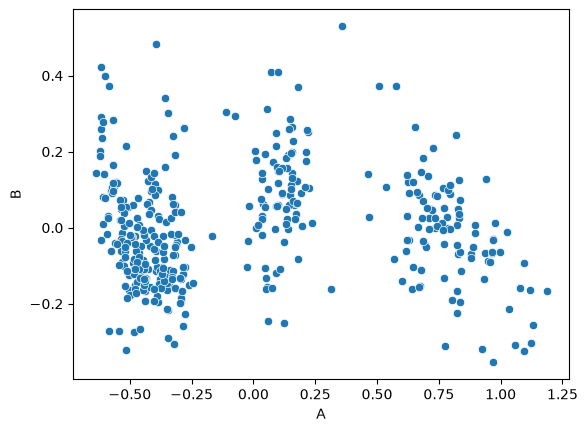

In [43]:
# plot in scatterplot
sns.scatterplot(x='A',y='B',data=df_scaled_pca)

Text(0.5, 1.0, 'After Scaling')

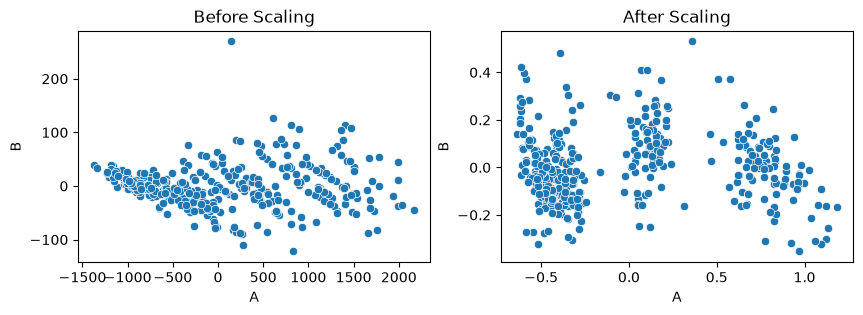

In [44]:
# compare before scaling 'df_pca' and after scaling 'df_scaled_pca' dataset
fig , axes = plt.subplots(1,2,figsize=(10,3))
sns.scatterplot(x='A',y='B',data=df_pca, ax=axes[0])
sns.scatterplot(x='A',y='B',data=df_scaled_pca, ax=axes[1])
axes[0].set_title("Before Scaling")
axes[1].set_title("After Scaling")

In [45]:
# use KMeans algorithm on 'df_scaled_pca'
# lets find the n_clusters first
wccs = []

In [47]:
for x in range(2,10):
    kmeans = KMeans(n_clusters=x)
    kmeans.fit(df_scaled_pca)
    wccs.append(kmeans.inertia_)

In [48]:
wccs

[31.64861933462629,
 12.740321678407772,
 10.566641127901363,
 9.065933321866831,
 7.060587289585654,
 6.8024951079570535,
 5.720751139529893,
 4.741730000418507]

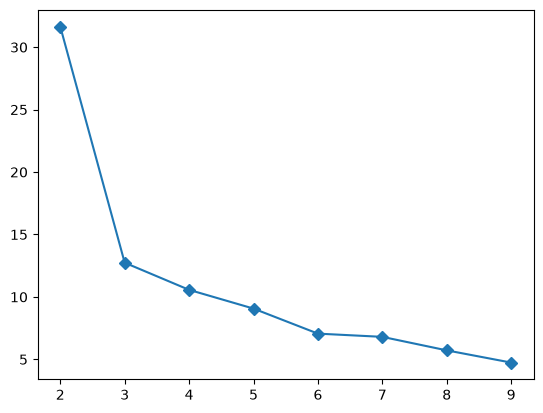

In [49]:
# plot 
plt.plot(range(2,10),wccs, marker='D')

In [51]:
# here on scaled dataset 'df_scaled_pca', since data fall hugely till 3 and after 3 less change in dataset, so ,we select n_clusters =3
# use KMeans algorithm with clusters = 3
kmeans = KMeans(n_clusters=3)
kmeans.fit(df_scaled_pca)
df_scaled_pca['label'] = kmeans.labels_

In [52]:
df_scaled_pca

,A,B,label
0,0.617214,-0.060181,0
1,0.771073,-0.132590,0
2,0.673647,-0.153374,0
3,0.644345,-0.103978,0
4,0.639947,-0.161542,0
...,...,...,...
387,-0.316001,-0.051247,1
388,-0.616682,0.423980,1
389,-0.344032,-0.291173,1
390,-0.408270,0.102095,1


<Axes: xlabel='A', ylabel='B'>

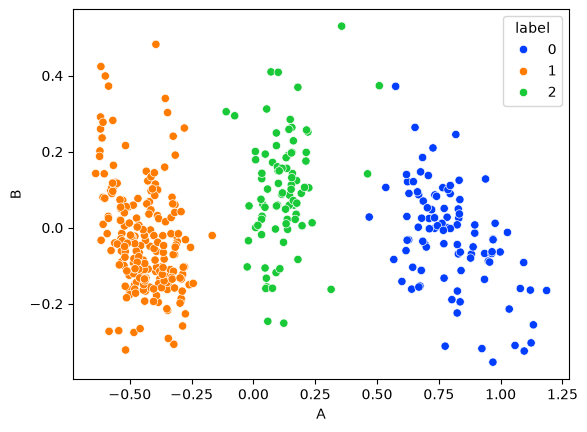

In [53]:
# plot in scatter
sns.scatterplot(x='A',y='B',data=df_scaled_pca, hue='label', palette='bright')

Text(0.5, 1.0, 'After Scalling Cluster')

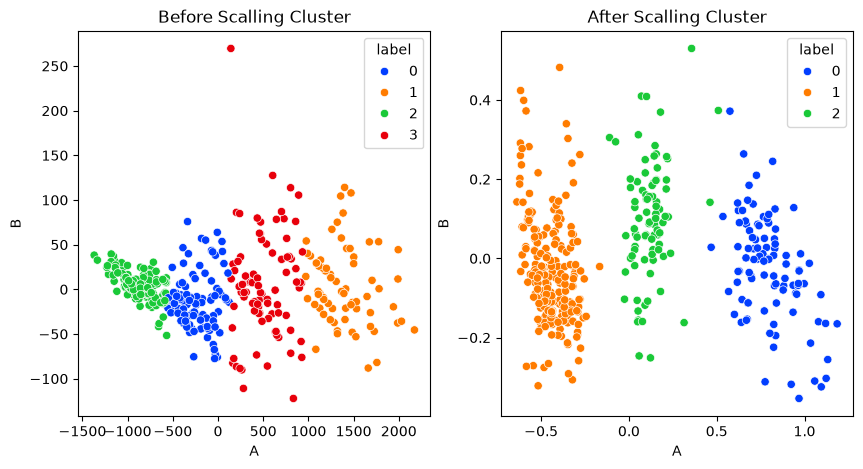

In [56]:
# compare before scaling 'df_pca' cluster and after scaling 'df_scaled_pca' cluster
fig, axes = plt.subplots(1,2, figsize=(10,5))
sns.scatterplot(x='A',y='B',data=df_pca, ax=axes[0], hue='label', palette='bright')
sns.scatterplot(x='A',y='B', data=df_scaled_pca, ax=axes[1], hue='label', palette='bright')
axes[0].set_title("Before Scalling Cluster")
axes[1].set_title("After Scalling Cluster")

In [57]:
data.shape

(398, 9)

In [58]:
df_pca.shape

(392, 3)

In [59]:
df_scaled_pca.shape

(392, 3)

In [60]:
df_scaled_pca.groupby('label')[['A','B']].count()

,A,B
label,,
0,100,100
1,205,205
2,87,87


In [64]:
df_scaled_pca[df_scaled_pca.label == 0]

,A,B,label
0,0.617214,-0.060181,0
1,0.771073,-0.132590,0
2,0.673647,-0.153374,0
3,0.644345,-0.103978,0
4,0.639947,-0.161542,0
...,...,...,...
288,0.740772,0.082595,0
289,0.535424,0.105903,0
290,0.768378,-0.006878,0
296,0.653622,0.263784,0


In [66]:
# lets add 'label' column from 'df_scaled_pca' to in original 'data' dataset
data.isna().sum()

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64

In [67]:
data = data.dropna()

In [68]:
data.isna().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64

In [69]:
data['label'] = df_scaled_pca['label']

In [78]:
data.isna().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
name            0
label           6
dtype: int64

In [79]:
data[data.label.isna()]

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name,label
392,27.0,4,151.0,90.0,2950,17.3,82,usa,chevrolet camaro,NaN
393,27.0,4,140.0,86.0,2790,15.6,82,usa,ford mustang gl,NaN
394,44.0,4,97.0,52.0,2130,24.6,82,europe,vw pickup,NaN
395,32.0,4,135.0,84.0,2295,11.6,82,usa,dodge rampage,NaN
396,28.0,4,120.0,79.0,2625,18.6,82,usa,ford ranger,NaN
397,31.0,4,119.0,82.0,2720,19.4,82,usa,chevy s-10,NaN


In [80]:
data.shape

(392, 10)

In [71]:
data.groupby('label')['mpg'].count()

label
0.0    100
1.0    202
2.0     84
Name: mpg, dtype: int64

In [81]:
# get only cluster 2 all clolumns value
data[data.label == 0]

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name,label
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu,0.0
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320,0.0
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite,0.0
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst,0.0
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino,0.0
...,...,...,...,...,...,...,...,...,...,...
288,18.2,8,318.0,135.0,3830,15.2,79,usa,dodge st. regis,0.0
289,16.9,8,350.0,155.0,4360,14.9,79,usa,buick estate wagon (sw),0.0
290,15.5,8,351.0,142.0,4054,14.3,79,usa,ford country squire (sw),0.0
296,27.4,4,121.0,80.0,2670,15.0,79,usa,amc spirit dl,0.0


In [82]:
data[data.label==1]

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name,label
14,24.0,4,113.0,95.0,2372,15.0,70,japan,toyota corona mark ii,1.0
18,27.0,4,97.0,88.0,2130,14.5,70,japan,datsun pl510,1.0
19,26.0,4,97.0,46.0,1835,20.5,70,europe,volkswagen 1131 deluxe sedan,1.0
20,25.0,4,110.0,87.0,2672,17.5,70,europe,peugeot 504,1.0
21,24.0,4,107.0,90.0,2430,14.5,70,europe,audi 100 ls,1.0
...,...,...,...,...,...,...,...,...,...,...
387,38.0,6,262.0,85.0,3015,17.0,82,usa,oldsmobile cutlass ciera (diesel),1.0
388,26.0,4,156.0,92.0,2585,14.5,82,usa,chrysler lebaron medallion,1.0
389,22.0,6,232.0,112.0,2835,14.7,82,usa,ford granada l,1.0
390,32.0,4,144.0,96.0,2665,13.9,82,japan,toyota celica gt,1.0


In [83]:
data[data.label==2]

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name,label
15,22.0,6,198.0,95.0,2833,15.5,70,usa,plymouth duster,2.0
16,18.0,6,199.0,97.0,2774,15.5,70,usa,amc hornet,2.0
17,21.0,6,200.0,85.0,2587,16.0,70,usa,ford maverick,2.0
24,21.0,6,199.0,90.0,2648,15.0,70,usa,amc gremlin,2.0
33,19.0,6,232.0,100.0,2634,13.0,71,usa,amc gremlin,2.0
...,...,...,...,...,...,...,...,...,...,...
360,30.7,6,145.0,76.0,3160,19.6,81,europe,volvo diesel,2.0
361,25.4,6,168.0,116.0,2900,12.6,81,japan,toyota cressida,2.0
380,36.0,4,120.0,88.0,2160,14.5,82,japan,nissan stanza xe,2.0
381,36.0,4,107.0,75.0,2205,14.5,82,japan,honda accord,2.0


C:\Users\lakpa\AppData\Local\Temp\ipykernel_24296\2535779101.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='label', y='mpg', data=data, palette='bright')


<Axes: xlabel='label', ylabel='mpg'>

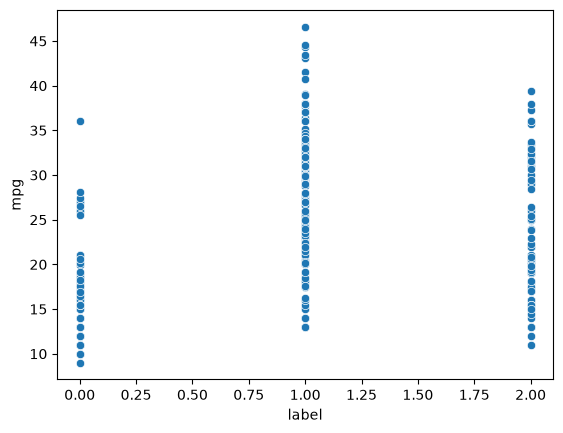

In [89]:
# plot 
sns.scatterplot(x='label', y='mpg', data=data, palette='bright')

In [86]:
df_pca

,A,B,label
0,536.437175,50.723576,3
1,730.333848,79.036747,3
2,470.973760,75.339924,3
3,466.393605,62.421740,3
4,481.660073,55.668193,3
...,...,...,...
387,-193.153983,-34.356847,0
388,-854.572860,-5.792902,2
389,-685.172071,20.228680,2
390,-359.508924,-35.546326,0
